# 06. 추가 실험: 가중회귀 · 강건회귀 · 이항 GLM · 반복 K-Fold · 도메인 파생 피처

**작성일**: 2026-09-16
**선행 노트북**: `05_improved_modeling.ipynb` (02 전처리 버그 수정이 반영된 데이터를 그대로 재사용)
**체크포인트/산출물 접두사**: `v4_` (03=`(접두사 없음)`, 04=`(접두사 없음)`, 05=`v3_` 와 겹치지 않게 구분)

## 이 노트북의 목적

2차 보고서 개정판 작성 후, "더 시도해볼만한 방법이 있는가?"라는 질문에 대해 제안했던
5가지 방향을 **전부** 실행하고 정직하게 검증한다.

1. **가중회귀(Weighted Regression)** — 배치마다 표본 크기(양품+불량수량)가 크게 다른데,
   지금까지 모든 모델이 108개 행을 동일한 신뢰도로 취급해 왔다는 점을 보정한다.
2. **강건회귀(Robust Regression)** — HuberRegressor/RANSACRegressor로, 05에서 수동으로
   찾아 제외했던 고-레버리지 관측치를 모델이 스스로 다운웨이트하게 한다.
3. **이항 GLM(Binomial GLM)** — 불량비율을 '연속값'이 아니라 원본 양품/불량 카운트에서
   나온 '이항비율'로 다시 정의해, 통계적으로 더 원리에 맞는 방식으로 접근한다.
4. **반복 K-Fold(Repeated K-Fold)** — 04/05에서 반복적으로 확인된 "Val 14건·K-Fold 1회
   만으로는 성능 추정이 너무 불안정하다"는 문제를 구조적으로 완화하기 위해, fold 분할을
   여러 번 반복해 신뢰구간까지 포함한 정직한 성능 추정치를 만든다. 이 노트북에서는
   하이퍼파라미터 선택과 최종 후보 비교 모두에 반복 K-Fold를 1차 기준으로 사용한다.
5. **도메인 파생 피처** — Zone 온도/OP 값의 '최솟값-최댓값 변동폭(range)'을 새 피처로
   추가해, 공정 안정성이라는 도메인 지식을 모델이 직접 활용할 수 있게 한다.

## 중요한 방법론적 차이 (04/05 대비)

지금까지 04/05는 "명시적 Val 14건 기준 그리드서치 → 사후 K-Fold로 안정성만 확인"하는
순서였다. 이 노트북은 **반복 K-Fold(5-Fold × 20회 = 100개 fold 점수) 자체를 1차
선택/평가 기준으로 승격**한다. 근거: 04/05에서 반복적으로 "Val 기준 최선"과 "Test 기준
최선"이 뒤집히는 사례가 나왔고, 이는 단일 14건 분할이 표본이 작을 때 너무 불안정한
기준이라는 뜻이었다. Test 세트는 이 노트북에서도 여전히 "최종 검증" 섹션에서 단
한 번만 연다 — 어떤 후보를 Test로 고르는 데 쓰지 않는다는 원칙은 그대로 유지한다.

## 진행상황 / 체크포인트

모든 반복 학습(가중회귀 그리드서치, 반복 K-Fold 등)에 tqdm 진행률 표시줄을 사용한다.
반복 K-Fold는 fold 수가 많아(최대 100개) 시간이 걸릴 수 있으므로, 체크포인트가 필요한
무거운 학습(RandomForest류)은 이번 노트북에서는 다루지 않고 04/05에서 이미 충분히
탐색이 끝난 선형계열/강건회귀/GLM에 집중한다 (RandomForest/XGBoost/LightGBM에 가중치를
적용하는 실험은 '다음 단계'로 남겨둔다).


In [2]:
# ===== 0. 환경 설정 =====
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import training_utils as tu

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "data_processed")
CKPT_DIR = os.path.join("..", "checkpoints")
FIG_DIR = os.path.join("..", "figures")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CKPT_PREFIX = "v4_"  # 03/04(접두사 없음)/05(v3_)와 겹치지 않는 이 노트북 전용 접두사

applied_font = tu.set_korean_font()
print("적용된 한글 폰트:", applied_font)


[한글 폰트] 'NanumGothicOTF' 적용 완료.
적용된 한글 폰트: NanumGothicOTF


## 1. 데이터 로드 (05에서 수정된 데이터 재사용)

02 노트북의 전처리 버그 수정이 반영된 `X_train_skew_corrected.csv` 등을 그대로
불러온다. Test 세트(`X_test_skew_corrected_DO_NOT_OPEN.csv`)는 이번에도 "최종 검증"
섹션 전까지 열지 않는다.


In [3]:
# ===== 1. 데이터 로드 =====
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_skew_corrected.csv"), index_col=0)
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val_skew_corrected.csv"), index_col=0)
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"), index_col=0)["불량비율"]
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv"), index_col=0)["불량비율"]

df_total = pd.read_csv(os.path.join(DATA_DIR, "df_total.csv"))  # ★ index_col 지정 안 함:
# df_total.csv는 배정번호가 이미 일반 컬럼이라, index_col=0으로 읽으면 배정번호가
# 인덱스가 되어버려 X_train.index(원래 df_total 행 라벨, 0~135)와 어긋난다
# (05 노트북에서 확립한 관례와 동일하게 기본 RangeIndex를 유지해야 함)

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)
print("df_total:", df_total.shape)

# 05에서 찾아낸(및 정정된) 고-레버리지 배정번호 3개 (position -> index 라벨 -> 배정번호
# 순서로 정확히 추적된 값. 05 노트북 및 2차 보고서 부록 E 참고)
leverage_df = pd.read_csv(os.path.join(DATA_DIR, "v3_leverage_analysis.csv"))
high_leverage_labels = leverage_df.loc[leverage_df["is_high_leverage"], "df_total_row_label"].tolist()
print("\n고-레버리지 관측치(df_total 행 라벨):", high_leverage_labels)
display(leverage_df)


X_train: (108, 26)  X_val: (14, 26)
y_train: (108,)  y_val: (14,)
df_total: (136, 42)

고-레버리지 관측치(df_total 행 라벨): [77, 25, 39]


,position_in_X_train,df_total_row_label,배정번호,leverage,불량비율,양품수량,불량수량,is_high_leverage
0,14,77,131758,1.000000,0.059940,15006,9,True
1,72,25,118005,0.992602,0.006682,59854,4,True
2,85,39,122460,0.954851,0.008657,11551,1,True
3,100,0,102410,0.470993,0.019785,15160,3,False
4,101,110,141554,0.443579,0.086962,75829,66,False
...,...,...,...,...,...,...,...,...
103,66,98,138084,0.110030,0.020638,14533,3,False
104,45,109,141145,0.109361,0.172706,30057,52,False
105,98,108,140920,0.107300,0.199038,60170,120,False
106,35,113,143068,0.092316,0.008353,59854,5,False


In [4]:
# train+val을 합친 데이터 (반복 K-Fold 등 test를 열지 않는 모든 평가에 사용)
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)
print("X_trainval:", X_trainval.shape, "(반복 K-Fold 등에 사용, test는 절대 포함하지 않음)")

# 05와 동일하게 두 변형을 함께 유지한다: 전체(all) vs 고-레버리지 3개 제외(drop_highlev)
drop_mask = ~X_trainval.index.isin(high_leverage_labels)
X_trainval_drop = X_trainval[drop_mask]
y_trainval_drop = y_trainval[drop_mask]
print("X_trainval_drop_highlev:", X_trainval_drop.shape)


X_trainval: (122, 26) (반복 K-Fold 등에 사용, test는 절대 포함하지 않음)
X_trainval_drop_highlev: (119, 26)


## 2. 도메인 파생 피처: Zone 온도/OP 변동폭(range) 추가

`add_range_features()`로 min/max 쌍이 모두 남아있는 센서에 대해 `{센서}_range`
피처를 추가한다. 새로 추가된 피처가 다중공선성을 다시 만들지 않는지 VIF로 재확인하고,
필요하면 (02/04와 동일한 기준인 |r|≥0.8) 상관관계 기반 제거를 적용한다.


In [5]:
# ===== 2. 도메인 파생 피처 추가 =====
X_trainval_range, new_range_cols = tu.add_range_features(X_trainval)
print(f"\n피처 수: {X_trainval.shape[1]} -> {X_trainval_range.shape[1]} (+{len(new_range_cols)})")


[range 피처 생성] min/max 쌍이 모두 있는 센서 9개에 대해 '_range' 피처를 추가하고, 완전공선성 방지를 위해 대응하는 '_max' 컬럼을 제거했습니다 (min은 유지):
  - 건조 1존 OP_range  (제거된 컬럼: 건조 1존 OP_max)
  - 건조 2존 OP_range  (제거된 컬럼: 건조 2존 OP_max)
  - 건조로 온도 2 Zone_range  (제거된 컬럼: 건조로 온도 2 Zone_max)
  - 세정기_range  (제거된 컬럼: 세정기_max)
  - 소입2존 OP_range  (제거된 컬럼: 소입2존 OP_max)
  - 소입로 CP 값_range  (제거된 컬럼: 소입로 CP 값_max)
  - 소입로 온도 1 Zone_range  (제거된 컬럼: 소입로 온도 1 Zone_max)
  - 소입로 온도 4 Zone_range  (제거된 컬럼: 소입로 온도 4 Zone_max)
  - 솔트 컨베이어 온도 1 Zone_range  (제거된 컬럼: 솔트 컨베이어 온도 1 Zone_max)

피처 수: 26 -> 26 (+9)


In [6]:
# 새로 추가된 range 피처가 다중공선성을 다시 만들지 않는지 확인 (|r|>=0.8 제거, 02와 동일 기준)
X_trainval_reduced, drop_log = tu.remove_multicollinear_features(X_trainval_range, threshold=0.8)
print(f"다중공선성 제거 후 피처 수: {X_trainval_range.shape[1]} -> {X_trainval_reduced.shape[1]}")
if drop_log:
    print("\n제거된 피처:")
    display(pd.DataFrame(drop_log))
else:
    print("(제거된 피처 없음 — range 피처가 기존 26개 피처와 |r|<0.8 수준의 독립적인 정보를 담고 있음)")

FEATURE_COLS_V4 = list(X_trainval_reduced.columns)
print(f"\n최종 06 피처 수: {len(FEATURE_COLS_V4)}개")


다중공선성 제거 후 피처 수: 26 -> 24

제거된 피처:


,dropped,kept,correlation
0,소입로 온도 1 Zone_range,소입로 온도 1 Zone_min,0.985105
1,솔트 컨베이어 온도 1 Zone_range,솔트 컨베이어 온도 1 Zone_min,0.825035



최종 06 피처 수: 24개


In [7]:
# VIF 재점검 (04/05와 동일한 기준: VIF>10이면 다중공선성 심각)
vif_v4 = tu.compute_vif(X_trainval_reduced)
display(vif_v4.head(10))
print(f"\nVIF 최댓값: {vif_v4['VIF'].max():.3f}  (VIF>10인 피처 수: {(vif_v4['VIF'] > 10).sum()}개)")

cond_number_v4 = np.linalg.cond(np.column_stack([np.ones(len(X_trainval_reduced)), X_trainval_reduced.values]))
print(f"설계행렬 조건수 (절편 포함): {cond_number_v4:.3e}  "
      f"({'정상' if cond_number_v4 < 1e10 else '주의: 근-특이 행렬 가능성'})")


VIF 계산:   0%|          | 0/24 [00:00<?, ?it/s]

,feature,VIF,is_high_vif
0,소입2존 OP_range,5.970944,False
1,소입로 온도 2 Zone_max,5.710197,False
2,소입2존 OP_min,4.181974,False
3,소입로 CP 값_range,4.124970,False
4,건조로 온도 1 Zone_min,3.981071,False
5,건조로 온도 2 Zone_min,3.969051,False
6,소입3존 OP_max,3.889792,False
7,소입로 CP 값_min,3.785558,False
8,소입로 온도 4 Zone_range,3.690008,False
9,소입로 온도 1 Zone_min,3.549445,False



VIF 최댓값: 5.971  (VIF>10인 피처 수: 0개)
설계행렬 조건수 (절편 포함): 1.020e+07  (정상)


In [8]:
# 최종 06 피처셋으로 train/val/trainval(all, drop_highlev) 을 모두 다시 슬라이스
X_train_v4 = X_trainval_reduced.loc[X_train.index]
X_val_v4 = X_trainval_reduced.loc[X_val.index]
X_trainval_v4 = X_trainval_reduced
X_trainval_v4_drop = X_trainval_reduced[drop_mask]

# 04/05와 동일한 원칙: 스케일러는 반드시 train 데이터에만 fit 한다.
# (피처 구성이 26개 -> 06에서 늘어났으므로, 05의 v3_final_minmax_scaler를 재사용하지
#  않고 새로 fit 한다 — 이유는 05가 02 버그 수정 후 v3_ 스케일러를 새로 만든 것과 동일)
from sklearn.preprocessing import MinMaxScaler

scaler_v4 = MinMaxScaler()
scaler_v4.fit(X_train_v4)

def _scale(df):
    return pd.DataFrame(scaler_v4.transform(df), index=df.index, columns=df.columns)

X_train_v4_scaled = _scale(X_train_v4)
X_val_v4_scaled = _scale(X_val_v4)
X_trainval_v4_scaled = _scale(X_trainval_v4)
X_trainval_v4_drop_scaled = _scale(X_trainval_v4_drop)

import joblib
joblib.dump(scaler_v4, os.path.join(CKPT_DIR, f"{CKPT_PREFIX}final_minmax_scaler.joblib"))
print("스케일링 완료. 컬럼 수:", X_train_v4_scaled.shape[1])


스케일링 완료. 컬럼 수: 24


## 3. 표본 가중치 설계: 배치 크기 기반 가중치

`compute_sample_weights()`로 `sqrt(양품수량+불량수량)`에 비례하는 가중치를 계산한다.
표본이 큰 배치일수록 불량비율 추정이 더 안정적이라는 통계적 근거(이항분포 표준오차
∝ 1/sqrt(n))에 따른 것이다.


In [9]:
# ===== 3. 표본 가중치 계산 =====
w_train = tu.compute_sample_weights(df_total, X_train_v4.index)
w_val = tu.compute_sample_weights(df_total, X_val_v4.index)
w_trainval = tu.compute_sample_weights(df_total, X_trainval_v4.index)
w_trainval_drop = tu.compute_sample_weights(df_total, X_trainval_v4_drop.index)

weight_summary = pd.DataFrame({
    "양품+불량 수량": (df_total.loc[X_trainval_v4.index, "양품수량"]
                    + df_total.loc[X_trainval_v4.index, "불량수량"]),
    "sample_weight(정규화됨)": w_trainval,
}).sort_values("양품+불량 수량")
print("가중치 분포 (표본 크기가 작을수록 가중치도 작음, 평균=1.0으로 정규화):")
display(weight_summary.describe())
display(weight_summary.head(3))
display(weight_summary.tail(3))


가중치 분포 (표본 크기가 작을수록 가중치도 작음, 평균=1.0으로 정규화):


,양품+불량 수량,sample_weight(정규화됨)
count,122.000000,122.000000
mean,44709.975410,1.000000
std,25712.506302,0.303889
min,8414.000000,0.453241
25%,29443.000000,0.847847
50%,42385.000000,1.017128
75%,60082.500000,1.211161
max,104761.000000,1.599292


,양품+불량 수량,sample_weight(정규화됨)
65,8414,0.453241
9,9023,0.469357
39,11552,0.531076


,양품+불량 수량,sample_weight(정규화됨)
20,90912,1.489836
87,97938,1.546335
7,104761,1.599292


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(weight_summary["양품+불량 수량"], weight_summary["sample_weight(정규화됨)"], alpha=0.6, edgecolor="k")
ax.set_xlabel("배치 표본 크기 (양품수량+불량수량)")
ax.set_ylabel("sample_weight (sqrt(n), 평균=1로 정규화)")
ax.set_title("배치 크기에 따른 표본 가중치 (06)")
ax.set_xscale("log")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "26_sample_weight_vs_batch_size.png"), dpi=120)
plt.show()
print("그림 저장: 26_sample_weight_vs_batch_size.png")


<Figure size 800x500 with 1 Axes>

그림 저장: 26_sample_weight_vs_batch_size.png


## 4. 반복 K-Fold(Repeated K-Fold) 평가 프레임워크 시범 적용

본격적인 실험 전에, 05의 최종 후보(Lasso, alpha=0.0007, 고-레버리지 3개 제외)를
반복 K-Fold(5-Fold × 20회)로 재평가해 "Val 14건 R²=0.1103"이라는 단일 점수가 실제로
얼마나 넓은 분포 안에 있는 값인지 먼저 확인한다.


In [11]:
from sklearn.linear_model import Lasso

baseline_repeated = tu.repeated_kfold_evaluate(
    Lasso, {"alpha": 0.0007, "max_iter": 20000}, X_trainval_v4_drop_scaled, y_trainval_drop,
    n_splits=5, n_repeats=20, random_state=RANDOM_STATE,
    desc="[기준선] Lasso(05 best, 06 피처셋 재적용) 반복 K-Fold",
)
print(f"반복 K-Fold(100개 fold) 평균 R² = {baseline_repeated['mean_R2']:.4f} "
      f"(표준편차={baseline_repeated['std_R2']:.4f}, 95% CI={tuple(round(v,4) for v in baseline_repeated['ci95_R2'])})")
print(f"참고: 05 노트북의 단일 Val 14건 R² = 0.1103 이었음 — 반복 K-Fold 신뢰구간 안에 "
      f"들어오는지 확인 필요.")


[기준선] Lasso(05 best, 06 피처셋 재적용) 반복 K-Fold:   0%|          | 0/100 [00:00<?, ?it/s]

반복 K-Fold(100개 fold) 평균 R² = -0.2001 (표준편차=0.3785, 95% CI=(-0.2743, -0.126))
참고: 05 노트북의 단일 Val 14건 R² = 0.1103 이었음 — 반복 K-Fold 신뢰구간 안에 들어오는지 확인 필요.


## 5. 실험 A: 가중회귀 (Weighted Ridge / Lasso / ElasticNet)

동일한 alpha 그리드에 대해 **비가중(unweighted)** vs **가중(weighted, sample_weight=
sqrt(n))** 학습을 모두 시도하고, 반복 K-Fold로 비교한다. 하이퍼파라미터 후보별 점수는
비가중 val R²(04/05와의 연속성을 위해)로도 참고하되, 최종 채택 기준은 반복 K-Fold
평균 R²로 통일한다.


In [12]:
from sklearn.linear_model import Ridge, ElasticNet

alpha_grid_linear = [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003, 0.005, 0.007, 0.01, 0.03, 0.05, 0.1, 0.3, 1.0]
ridge_param_grid = [{"alpha": a} for a in alpha_grid_linear]
lasso_param_grid = [{"alpha": a, "max_iter": 20000} for a in alpha_grid_linear]
en_param_grid = [{"alpha": a, "l1_ratio": l1, "max_iter": 20000}
                  for a in [0.0005, 0.001, 0.005, 0.01, 0.05]
                  for l1 in [0.1, 0.3, 0.5, 0.7, 0.9]]



In [13]:
# 각 후보가 '최종 Test 검증(10절)'에서 정확히 어떤 데이터/피처공간으로 다시 학습되어야
# 하는지를 후보 이름(label)별로 저장해 둔다. 10절에서 label 문자열을 다시 파싱해 유추하는
# 방식은 후보 이름 형식이 조금만 달라져도 엉뚱한 데이터로 재학습하는 오류를 만들기 쉬우므로
# (실제로 초안 작성 중 이 문제를 발견해 이렇게 고쳤다 — 아래 설명 참고), 각 실험(A~D, legacy)의
# 최종 후보를 확정하는 시점에 '이 후보를 어떻게 다시 학습해서 예측하면 되는지'를 직접 등록한다.
#
# ★ 왜 label 파싱이 위험한가?: 예를 들어 8절(Ablation)의 두 후보 이름은
# "ElasticNet_weighted + range 피처" 와 "ElasticNet_weighted (range 피처 없음, 05와 동일)"
# 인데, 둘 다 실제로는 '고-레버리지 3개 제외(105건)' 데이터로 학습된 것이다. 그런데 후보
# 이름에 "range"라는 글자가 들어있다는 이유만으로 "all(108건)"로 오해하는 식의 버그가
# 나기 쉽다(글자 매칭은 '이 후보가 어떤 피처 공간/행 집합을 썼는지'를 신뢰성 있게 알려주지
# 못한다). 그래서 아래처럼 각 후보를 등록하는 시점에 실제 학습 데이터를 클로저(closure)로
# 캡처해 둔다.
CANDIDATE_TEST_PREDICTORS = {}  # {후보 이름: (predict_fn(X_new_test) -> 예측배열, space_tag)}
# space_tag: "v4"(range 피처 포함 24개 피처 공간, 대부분의 후보) 또는
#            "noRange"(range 피처 없는 05와 동일한 26개 피처 공간, 8절 ablation의 '제외' 후보 전용)


def _register_sklearn_predictor(label, model_class, params, X_fit, y_fit, sample_weight=None, space_tag="v4"):
    '''sklearn 스타일 추정기(fit/predict)를 쓰는 후보를 등록한다. Test 검증 시점에
    predict_fn(X_test)을 호출하면, 그 순간 X_fit/y_fit(과 sample_weight)로 새로 fit()한
    뒤 X_test에 대한 예측을 반환한다 (지금까지 모든 노트북과 동일하게, 최종 모델은
    train+val 전체로 다시 학습해서 Test에 적용하는 방식).'''
    def _predict(X_new):
        try:
            model = model_class(random_state=RANDOM_STATE, **params)
        except TypeError:
            model = model_class(**params)
        if sample_weight is not None:
            model.fit(X_fit, y_fit, sample_weight=sample_weight)
        else:
            model.fit(X_fit, y_fit)
        return model.predict(X_new)
    CANDIDATE_TEST_PREDICTORS[label] = (_predict, space_tag)


def _register_glm_predictor(label, alpha, X_fit, good_fit, bad_fit, space_tag="v4"):
    '''이항 GLM 후보를 등록한다 (statsmodels GLM은 sklearn 인터페이스가 달라 별도 함수로 분리).'''
    def _predict(X_new):
        glm_res = tu.fit_binomial_glm(np.asarray(X_fit, dtype=float), good_fit, bad_fit, alpha=alpha)
        return tu.predict_binomial_glm(glm_res, np.asarray(X_new, dtype=float))
    CANDIDATE_TEST_PREDICTORS[label] = (_predict, space_tag)


In [14]:
def _select_best_by_repeated_kfold(model_class, param_grid, X, y, sample_weight, label):
    '''param_grid 각 후보에 대해 반복 K-Fold(5x10, 가중회귀는 시간이 걸리므로 그리드
    탐색 단계에서는 n_repeats를 10으로 줄이고, 최종 채택된 1개만 5x20으로 재평가한다)로
    평균 R2를 계산해 가장 좋은 후보를 고른다.'''
    rows = []
    best = None
    for params in tqdm(param_grid, desc=f"{label} 그리드서치(반복 K-Fold 5x10)"):
        res = tu.repeated_kfold_evaluate(
            model_class, params, X, y, n_splits=5, n_repeats=10, random_state=RANDOM_STATE,
            sample_weight=sample_weight, desc=None,
        )
        row = {**params, "mean_R2": res["mean_R2"], "std_R2": res["std_R2"]}
        rows.append(row)
        if best is None or res["mean_R2"] > best[1]["mean_R2"]:
            best = (params, res)
    results_df = pd.DataFrame(rows).sort_values("mean_R2", ascending=False).reset_index(drop=True)
    return best[0], results_df


In [15]:
# --- Ridge: 비가중 vs 가중 ---
ridge_unw_params, ridge_unw_results = _select_best_by_repeated_kfold(
    Ridge, ridge_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, None, "Ridge(비가중)")
ridge_w_params, ridge_w_results = _select_best_by_repeated_kfold(
    Ridge, ridge_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, w_trainval_drop, "Ridge(가중)")

print("Ridge 비가중 최적:", ridge_unw_params, " mean_R2=", ridge_unw_results.iloc[0]["mean_R2"])
print("Ridge 가중 최적  :", ridge_w_params, " mean_R2=", ridge_w_results.iloc[0]["mean_R2"])


Ridge(비가중) 그리드서치(반복 K-Fold 5x10):   0%|          | 0/14 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

...

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Ridge 비가중 최적: {'alpha': 1.0}  mean_R2= -0.2912682520550267
Ridge 가중 최적  : {'alpha': 1.0}  mean_R2= -0.19705595744439044


In [16]:
# --- Lasso: 비가중 vs 가중 ---
lasso_unw_params, lasso_unw_results = _select_best_by_repeated_kfold(
    Lasso, lasso_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, None, "Lasso(비가중)")
lasso_w_params, lasso_w_results = _select_best_by_repeated_kfold(
    Lasso, lasso_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, w_trainval_drop, "Lasso(가중)")

print("Lasso 비가중 최적:", lasso_unw_params, " mean_R2=", lasso_unw_results.iloc[0]["mean_R2"])
print("Lasso 가중 최적  :", lasso_w_params, " mean_R2=", lasso_w_results.iloc[0]["mean_R2"])


Lasso(비가중) 그리드서치(반복 K-Fold 5x10):   0%|          | 0/14 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

...

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

Lasso 비가중 최적: {'alpha': 0.005, 'max_iter': 20000}  mean_R2= -0.1618208195872815
Lasso 가중 최적  : {'alpha': 0.001, 'max_iter': 20000}  mean_R2= -0.11336907431032538


In [17]:
# --- ElasticNet: 비가중 vs 가중 ---
en_unw_params, en_unw_results = _select_best_by_repeated_kfold(
    ElasticNet, en_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, None, "ElasticNet(비가중)")
en_w_params, en_w_results = _select_best_by_repeated_kfold(
    ElasticNet, en_param_grid, X_trainval_v4_drop_scaled, y_trainval_drop, w_trainval_drop, "ElasticNet(가중)")

print("ElasticNet 비가중 최적:", en_unw_params, " mean_R2=", en_unw_results.iloc[0]["mean_R2"])
print("ElasticNet 가중 최적  :", en_w_params, " mean_R2=", en_w_results.iloc[0]["mean_R2"])


ElasticNet(비가중) 그리드서치(반복 K-Fold 5x10):   0%|          | 0/25 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

...

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

ElasticNet 비가중 최적: {'alpha': 0.005, 'l1_ratio': 0.3, 'max_iter': 20000}  mean_R2= -0.1539725802748038
ElasticNet 가중 최적  : {'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 20000}  mean_R2= -0.10538769407419349


In [18]:
# 각 최적 후보를 5x20 반복 K-Fold로 재평가해 최종 비교표에 추가
weighted_experiment_candidates = [
    ("Ridge_unweighted", Ridge, ridge_unw_params, None),
    ("Ridge_weighted", Ridge, ridge_w_params, w_trainval_drop),
    ("Lasso_unweighted", Lasso, lasso_unw_params, None),
    ("Lasso_weighted", Lasso, lasso_w_params, w_trainval_drop),
    ("ElasticNet_unweighted", ElasticNet, en_unw_params, None),
    ("ElasticNet_weighted", ElasticNet, en_w_params, w_trainval_drop),
]

experiment_a_rows = []
for label, model_class, params, weight in tqdm(weighted_experiment_candidates, desc="실험 A 후보 최종 재평가(5x20)"):
    res = tu.repeated_kfold_evaluate(
        model_class, params, X_trainval_v4_drop_scaled, y_trainval_drop,
        n_splits=5, n_repeats=20, random_state=RANDOM_STATE, sample_weight=weight, desc=None,
    )
    experiment_a_rows.append({
        "실험": "A. 가중회귀", "후보": label, "params": params,
        "반복KFold_mean_R2": res["mean_R2"], "반복KFold_std_R2": res["std_R2"],
        "반복KFold_95CI_low": res["ci95_R2"][0], "반복KFold_95CI_high": res["ci95_R2"][1],
    })
    _register_sklearn_predictor(label, model_class, params, X_trainval_v4_drop_scaled, y_trainval_drop,
                                 sample_weight=weight, space_tag="v4")

experiment_a_df = pd.DataFrame(experiment_a_rows).sort_values("반복KFold_mean_R2", ascending=False).reset_index(drop=True)
display(experiment_a_df)


실험 A 후보 최종 재평가(5x20):   0%|          | 0/6 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

Ridge 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

ElasticNet 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,A. 가중회귀,ElasticNet_weighted,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
1,A. 가중회귀,Lasso_weighted,"{'alpha': 0.001, 'max_iter': 20000}",-0.099025,0.208485,-0.139888,-0.058162
2,A. 가중회귀,ElasticNet_unweighted,"{'alpha': 0.005, 'l1_ratio': 0.3, 'max_iter': ...",-0.138023,0.257442,-0.188482,-0.087565
3,A. 가중회귀,Lasso_unweighted,"{'alpha': 0.005, 'max_iter': 20000}",-0.149293,0.276799,-0.203546,-0.095041
4,A. 가중회귀,Ridge_weighted,{'alpha': 1.0},-0.180217,0.378428,-0.254389,-0.106045
5,A. 가중회귀,Ridge_unweighted,{'alpha': 1.0},-0.274368,0.515769,-0.375458,-0.173277


## 6. 실험 B: 강건회귀 (HuberRegressor / RANSACRegressor)

이상치(특히 05에서 찾은 고-레버리지 관측치)에 덜 민감한 회귀 방법을 시도한다. 이번에는
**고-레버리지 3개를 수동으로 빼지 않은 전체(all, 108건)** 데이터로 시도하는 것이
포인트다 — 강건회귀가 "사람이 수동으로 제외"하는 것과 비슷한 효과를 스스로 낼 수
있는지 확인하기 위함이다.


In [19]:
from sklearn.linear_model import HuberRegressor, RANSACRegressor

huber_param_grid = [{"epsilon": eps, "alpha": a, "max_iter": 5000}
                     for eps in [1.1, 1.35, 1.5, 2.0]
                     for a in [0.0001, 0.001, 0.01, 0.1]]
ransac_param_grid = [{"min_samples": ms, "residual_threshold": rt}
                      for ms in [0.5, 0.7, 0.9]
                      for rt in [None, 0.01, 0.02, 0.05]]

huber_best_params, huber_results = _select_best_by_repeated_kfold(
    HuberRegressor, huber_param_grid, X_trainval_v4_scaled, y_trainval, None, "HuberRegressor(all, 108건)")
print("HuberRegressor 최적:", huber_best_params, " mean_R2=", huber_results.iloc[0]["mean_R2"])
display(huber_results.head(5))


HuberRegressor(all, 108건) 그리드서치(반복 K-Fold 5x10):   0%|          | 0/16 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

...

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

HuberRegressor 최적: {'epsilon': 1.5, 'alpha': 0.1, 'max_iter': 5000}  mean_R2= -0.5104357106541978


,epsilon,alpha,max_iter,mean_R2,std_R2
0,1.50,0.10,5000,-0.510436,1.351349
1,1.35,0.10,5000,-0.515417,1.279440
2,2.00,0.10,5000,-0.633416,1.703854
3,1.50,0.01,5000,-0.652516,1.942941
4,1.35,0.01,5000,-0.659331,1.867287


In [20]:
from sklearn.linear_model import LinearRegression

# RANSACRegressor는 내부적으로 무작위 부분표본을 반복 추출하므로(자체 random_state
# 필요), grid_search 헬퍼 대신 직접 반복 K-Fold로 평가한다.
ransac_rows = []
for params in tqdm(ransac_param_grid, desc="RANSACRegressor(all, 108건) 그리드서치(반복 K-Fold 5x10)"):
    res = tu.repeated_kfold_evaluate(
        RANSACRegressor, {**params, "estimator": LinearRegression()},
        X_trainval_v4_scaled, y_trainval, n_splits=5, n_repeats=10,
        random_state=RANDOM_STATE, desc=None,
    )
    ransac_rows.append({**params, "mean_R2": res["mean_R2"], "std_R2": res["std_R2"]})
ransac_results = pd.DataFrame(ransac_rows).sort_values("mean_R2", ascending=False).reset_index(drop=True)
ransac_best_params = {**ransac_results.iloc[0].drop(["mean_R2", "std_R2"]).dropna().to_dict()}
print("RANSACRegressor 최적:", ransac_best_params, " mean_R2=", ransac_results.iloc[0]["mean_R2"])
display(ransac_results.head(5))


RANSACRegressor(all, 108건) 그리드서치(반복 K-Fold 5x10):   0%|          | 0/12 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

...

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x10) 평가:   0%|          | 0/50 [00:00<?, ?it/s]

RANSACRegressor 최적: {'min_samples': 0.5, 'residual_threshold': 0.05}  mean_R2= -0.5939409210153588


,min_samples,residual_threshold,mean_R2,std_R2
0,0.5,0.05,-0.593941,1.971850
1,0.7,0.05,-0.614867,1.329953
2,0.9,0.05,-0.653081,1.799989
3,0.9,0.02,-0.924042,2.414906
4,0.9,NaN,-1.212877,3.070184


In [21]:
robust_experiment_candidates = [
    ("HuberRegressor(all)", HuberRegressor, huber_best_params, X_trainval_v4_scaled, y_trainval, None),
    ("RANSACRegressor(all)", RANSACRegressor, {**ransac_best_params, "estimator": LinearRegression()},
     X_trainval_v4_scaled, y_trainval, None),
]

experiment_b_rows = []
for label, model_class, params, X_ev, y_ev, weight in tqdm(robust_experiment_candidates, desc="실험 B 후보 최종 재평가(5x20)"):
    res = tu.repeated_kfold_evaluate(
        model_class, params, X_ev, y_ev, n_splits=5, n_repeats=20,
        random_state=RANDOM_STATE, sample_weight=weight, desc=None,
    )
    experiment_b_rows.append({
        "실험": "B. 강건회귀", "후보": label, "params": str({k: v for k, v in params.items() if k != "estimator"}),
        "반복KFold_mean_R2": res["mean_R2"], "반복KFold_std_R2": res["std_R2"],
        "반복KFold_95CI_low": res["ci95_R2"][0], "반복KFold_95CI_high": res["ci95_R2"][1],
    })
    _register_sklearn_predictor(label, model_class, params, X_ev, y_ev, sample_weight=weight, space_tag="v4")

experiment_b_df = pd.DataFrame(experiment_b_rows).sort_values("반복KFold_mean_R2", ascending=False).reset_index(drop=True)
display(experiment_b_df)


실험 B 후보 최종 재평가(5x20):   0%|          | 0/2 [00:00<?, ?it/s]

HuberRegressor 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

RANSACRegressor 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,B. 강건회귀,HuberRegressor(all),"{'epsilon': 1.5, 'alpha': 0.1, 'max_iter': 5000}",-0.369834,0.999883,-0.565811,-0.173857
1,B. 강건회귀,RANSACRegressor(all),"{'min_samples': 0.5, 'residual_threshold': 0.05}",-0.491093,1.435182,-0.772389,-0.209798


## 7. 실험 C: 이항 GLM (Binomial GLM, 원본 카운트 기반)

`fit_binomial_glm()` / `predict_binomial_glm()`으로, 불량비율을 연속값이 아니라
'양품/불량 카운트에서 나온 이항비율'로 다시 정의해 적합한다. statsmodels GLM은
sklearn과 인터페이스가 달라(체크포인트 학습 루프 없이 한 번에 적합) 별도의 반복
K-Fold 루프를 직접 작성한다.


In [22]:
def glm_repeated_kfold(X, good_counts, bad_counts, n_splits=5, n_repeats=20, random_state=42,
                        alpha=0.0, L1_wt=0.0, desc=None):
    '''이항 GLM 전용 반복 K-Fold 평가 루프. statsmodels GLM은 sklearn Estimator
    인터페이스(fit/predict가 동일 시그니처)를 따르지 않으므로 repeated_kfold_evaluate()를
    그대로 재사용할 수 없어, 동일한 로직(RepeatedKFold + evaluate_regression)을 GLM에
    맞게 직접 구현한다. alpha/L1_wt는 tu.fit_binomial_glm()에 그대로 전달된다.'''
    from sklearn.model_selection import RepeatedKFold

    X_arr = np.asarray(X, dtype=float)
    good_arr = np.asarray(good_counts, dtype=float)
    bad_arr = np.asarray(bad_counts, dtype=float)
    y_rate = bad_arr / (bad_arr + good_arr) * 100.0  # 불량비율(%) 스케일 (make_defect_rate와 동일 정의)

    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    rows = []
    splits = list(rkf.split(X_arr))
    desc = desc or f"이항 GLM 반복 K-Fold({n_splits}x{n_repeats}) 평가"
    for i, (train_idx, val_idx) in enumerate(tqdm(splits, desc=desc)):
        glm_res = tu.fit_binomial_glm(X_arr[train_idx], good_arr[train_idx], bad_arr[train_idx],
                                       alpha=alpha, L1_wt=L1_wt)
        pred = tu.predict_binomial_glm(glm_res, X_arr[val_idx])
        metrics = tu.evaluate_regression(y_rate[val_idx], pred)
        rows.append({"repeat": i // n_splits, "fold": i % n_splits, **metrics})

    fold_scores = pd.DataFrame(rows)
    m, s, n = fold_scores["R2"].mean(), fold_scores["R2"].std(), len(fold_scores)
    se = s / np.sqrt(n)
    return {
        "fold_scores": fold_scores, "mean_R2": m, "std_R2": s,
        "ci95_R2": (m - 1.96 * se, m + 1.96 * se),
        "mean_RMSE": fold_scores["RMSE"].mean(), "mean_MAE": fold_scores["MAE"].mean(),
    }


In [23]:
# 먼저 train 전체로 한 번 정규화 없이 적합해 계수/유의성을 살펴본다 (all, 108건 기준).
# ★ summary()의 표준오차/p-value는 정규화 없는 적합에서만 의미가 있으므로 참고용으로만 본다.
glm_full = tu.fit_binomial_glm(
    X_trainval_v4_scaled.values,
    df_total.loc[X_trainval_v4_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_scaled.index, "불량수량"].values,
)
print(glm_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  122
Model:                            GLM   Df Residuals:                       97
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -783.87
Date:                Wed, 16 Sep 2026   Deviance:                       1086.4
Time:                        23:52:23   Pearson chi2:                 1.22e+03
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9903
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.1322      0.723    -15.391      0.0

In [24]:
# ★ 중요한 발견: 정규화 없는(alpha=0) 이항 GLM을 그대로 반복 K-Fold로 평가하면 무슨 일이
# 벌어지는지 먼저 확인한다 (n_repeats=3으로 줄여 빠르게 확인 — 아래에서 보듯 이 결과 자체가
# '정규화가 왜 필요한지'를 보여주는 증거이므로, 문제를 겪지 않는 정규화된 버전과는 별도로 취급한다).
glm_unregularized_check = glm_repeated_kfold(
    X_trainval_v4_scaled.values,
    df_total.loc[X_trainval_v4_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_scaled.index, "불량수량"].values,
    n_splits=5, n_repeats=3, random_state=RANDOM_STATE, alpha=0.0,
    desc="[문제 확인용] 이항 GLM(정규화 없음, all) 반복 K-Fold(5x3, 축소 실행)",
)
print(f"정규화 없는 이항 GLM 반복 K-Fold 평균 R² = {glm_unregularized_check['mean_R2']:.3e} "
      f"(표준편차={glm_unregularized_check['std_R2']:.3e})")
print("-> 배치별 표본 크기가 수십~6만 건까지 극단적으로 차이 나는 데이터에서, 정규화 없는 "
      "이항 GLM은 일부 fold에서 계수가 발산해 예측이 수치적으로 폭발한다 (아래 정규화된 "
      "버전과 비교할 것 — 이 결과는 최종 비교표에는 포함하지 않는다. 폭발한 값 하나가 "
      "표를 압도해 다른 후보들과 공정하게 비교할 수 없기 때문이다).")


[문제 확인용] 이항 GLM(정규화 없음, all) 반복 K-Fold(5x3, 축소 실행):   0%|          | 0/15 [00:00<?, ?it/s]

정규화 없는 이항 GLM 반복 K-Fold 평균 R² = -7.097e+04 (표준편차=2.428e+05)
-> 배치별 표본 크기가 수십~6만 건까지 극단적으로 차이 나는 데이터에서, 정규화 없는 이항 GLM은 일부 fold에서 계수가 발산해 예측이 수치적으로 폭발한다 (아래 정규화된 버전과 비교할 것 — 이 결과는 최종 비교표에는 포함하지 않는다. 폭발한 값 하나가 표를 압도해 다른 후보들과 공정하게 비교할 수 없기 때문이다).


In [25]:
# 정규화(alpha>0, L2) 그리드서치: 배치 크기 편차로 인한 발산을 억제할 수 있는 최소한의
# alpha를 반복 K-Fold(5x5, 그리드 탐색 단계라 축소)로 찾는다.
glm_alpha_grid = [0.5, 1, 2, 5, 10, 20, 50]

def _select_best_glm_alpha(X, good, bad, label):
    rows = []
    best = None
    for a in tqdm(glm_alpha_grid, desc=f"{label} 정규화 강도(alpha) 탐색(반복 K-Fold 5x5)"):
        res = glm_repeated_kfold(X, good, bad, n_splits=5, n_repeats=5, random_state=RANDOM_STATE,
                                  alpha=a, L1_wt=0.0, desc=None)
        rows.append({"alpha": a, "mean_R2": res["mean_R2"], "std_R2": res["std_R2"]})
        if best is None or res["mean_R2"] > best[1]:
            best = (a, res["mean_R2"])
    return best[0], pd.DataFrame(rows).sort_values("mean_R2", ascending=False).reset_index(drop=True)

glm_alpha_all, glm_alpha_all_results = _select_best_glm_alpha(
    X_trainval_v4_scaled.values,
    df_total.loc[X_trainval_v4_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_scaled.index, "불량수량"].values,
    "BinomialGLM(all)")
glm_alpha_drop, glm_alpha_drop_results = _select_best_glm_alpha(
    X_trainval_v4_drop_scaled.values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "불량수량"].values,
    "BinomialGLM(drop_highlev)")

print("BinomialGLM(all) 최적 alpha:", glm_alpha_all)
display(glm_alpha_all_results)
print("BinomialGLM(drop_highlev) 최적 alpha:", glm_alpha_drop)
display(glm_alpha_drop_results)


BinomialGLM(all) 정규화 강도(alpha) 탐색(반복 K-Fold 5x5):   0%|          | 0/7 [00:00<?, ?it/s]

이항 GLM 반복 K-Fold(5x5) 평가:   0%|          | 0/25 [00:00<?, ?it/s]

이항 GLM 반복 K-Fold(5x5) 평가:   0%|          | 0/25 [00:00<?, ?it/s]

이항 GLM 반복 K-Fold(5x5) 평가:   0%|          | 0/25 [00:00<?, ?it/s]

이항 GLM 반복 K-Fold(5x5) 평가:   0%|          | 0/25 [00:00<?, ?it/s]

...

이항 GLM 반복 K-Fold(5x5) 평가:   0%|          | 0/25 [00:00<?, ?it/s]

BinomialGLM(all) 최적 alpha: 1


,alpha,mean_R2,std_R2
0,1.0,-0.593290,0.944414
1,0.5,-0.618748,1.134817
2,2.0,-0.731774,1.068329
3,5.0,-1.325640,1.811940
4,10.0,-2.574332,3.321894
5,20.0,-5.941641,7.101713
6,50.0,-21.885394,23.542095


BinomialGLM(drop_highlev) 최적 alpha: 0.5


,alpha,mean_R2,std_R2
0,0.5,-0.400349,0.533839
1,1.0,-0.458930,0.616389
2,2.0,-0.607465,0.831216
3,5.0,-1.127712,1.532601
4,10.0,-2.204041,2.848023
5,20.0,-5.136269,6.114961
6,50.0,-19.250499,20.477208


In [26]:
glm_repeated_all = glm_repeated_kfold(
    X_trainval_v4_scaled.values,
    df_total.loc[X_trainval_v4_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_scaled.index, "불량수량"].values,
    n_splits=5, n_repeats=20, random_state=RANDOM_STATE, alpha=glm_alpha_all,
    desc="이항 GLM(정규화, all, 108건) 반복 K-Fold",
)
glm_repeated_drop = glm_repeated_kfold(
    X_trainval_v4_drop_scaled.values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "불량수량"].values,
    n_splits=5, n_repeats=20, random_state=RANDOM_STATE, alpha=glm_alpha_drop,
    desc="이항 GLM(정규화, 고-레버리지 제외, 105건) 반복 K-Fold",
)

_register_glm_predictor(
    "BinomialGLM(all)", glm_alpha_all, X_trainval_v4_scaled.values,
    df_total.loc[X_trainval_v4_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_scaled.index, "불량수량"].values, space_tag="v4",
)
_register_glm_predictor(
    "BinomialGLM(drop_highlev)", glm_alpha_drop, X_trainval_v4_drop_scaled.values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "양품수량"].values,
    df_total.loc[X_trainval_v4_drop_scaled.index, "불량수량"].values, space_tag="v4",
)

experiment_c_df = pd.DataFrame([
    {"실험": "C. 이항 GLM", "후보": "BinomialGLM(all)", "params": f"logit link, L2 정규화 alpha={glm_alpha_all}",
     "반복KFold_mean_R2": glm_repeated_all["mean_R2"], "반복KFold_std_R2": glm_repeated_all["std_R2"],
     "반복KFold_95CI_low": glm_repeated_all["ci95_R2"][0], "반복KFold_95CI_high": glm_repeated_all["ci95_R2"][1]},
    {"실험": "C. 이항 GLM", "후보": "BinomialGLM(drop_highlev)", "params": f"logit link, L2 정규화 alpha={glm_alpha_drop}",
     "반복KFold_mean_R2": glm_repeated_drop["mean_R2"], "반복KFold_std_R2": glm_repeated_drop["std_R2"],
     "반복KFold_95CI_low": glm_repeated_drop["ci95_R2"][0], "반복KFold_95CI_high": glm_repeated_drop["ci95_R2"][1]},
])
display(experiment_c_df)


이항 GLM(정규화, all, 108건) 반복 K-Fold:   0%|          | 0/100 [00:00<?, ?it/s]

이항 GLM(정규화, 고-레버리지 제외, 105건) 반복 K-Fold:   0%|          | 0/100 [00:00<?, ?it/s]

,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,C. 이항 GLM,BinomialGLM(all),"logit link, L2 정규화 alpha=1",-0.498043,0.739862,-0.643056,-0.353030
1,C. 이항 GLM,BinomialGLM(drop_highlev),"logit link, L2 정규화 alpha=0.5",-0.316242,0.444995,-0.403461,-0.229023


## 8. 실험 D: 도메인 파생 피처(range)의 기여도 확인 (Ablation)

2절에서 추가한 range 피처가 실제로 성능에 기여하는지, 지금까지의 최선 후보(가중/비가중
Lasso 또는 Ridge 중 실험 A 1위)를 "range 피처 포함 vs 제외"로 나눠 반복 K-Fold로
직접 비교한다 — 피처를 늘렸다고 항상 좋아지는 것은 아니므로 정직하게 확인한다.


In [27]:
best_a_row = experiment_a_df.iloc[0]
best_a_label, best_a_params = best_a_row["후보"], best_a_row["params"]
best_a_model_class = {"Ridge": Ridge, "Lasso": Lasso, "ElasticNet": ElasticNet}[best_a_label.split("_")[0]]
best_a_weight = w_trainval_drop if "weighted" in best_a_label else None
print("실험 A 1위 후보:", best_a_label, best_a_params)

# "range 피처 제외" 비교군: add_range_features()를 적용하지 않은 05와 동일한 원본
# 26개 피처를 별도로 스케일링해서 만든다 (add_range_features가 max 컬럼을 range로
# 대체하므로, X_trainval_v4에서 range 컬럼만 빼면 max 컬럼이 아예 없는 상태가 되어
# '05와 동일한 26개'가 되지 않는다 -> 반드시 원본 X_train/X_trainval에서 새로 스케일링)
scaler_noRange = MinMaxScaler()
scaler_noRange.fit(X_train)  # X_train: 2절 이전, range 피처를 추가하지 않은 원본 26개 피처
X_trainval_drop_noRange_scaled = pd.DataFrame(
    scaler_noRange.transform(X_trainval_drop), index=X_trainval_drop.index, columns=X_trainval_drop.columns)

res_with_range = tu.repeated_kfold_evaluate(
    best_a_model_class, best_a_params, X_trainval_v4_drop_scaled, y_trainval_drop,
    n_splits=5, n_repeats=20, random_state=RANDOM_STATE, sample_weight=best_a_weight,
    desc=f"{best_a_label} (range 피처 포함) 반복 K-Fold",
)
res_without_range = tu.repeated_kfold_evaluate(
    best_a_model_class, best_a_params, X_trainval_drop_noRange_scaled, y_trainval_drop,
    n_splits=5, n_repeats=20, random_state=RANDOM_STATE, sample_weight=best_a_weight,
    desc=f"{best_a_label} (range 피처 제외, 05와 동일 26개) 반복 K-Fold",
)

_register_sklearn_predictor(f"{best_a_label} + range 피처", best_a_model_class, best_a_params,
                             X_trainval_v4_drop_scaled, y_trainval_drop, sample_weight=best_a_weight, space_tag="v4")
_register_sklearn_predictor(f"{best_a_label} (range 피처 없음, 05와 동일)", best_a_model_class, best_a_params,
                             X_trainval_drop_noRange_scaled, y_trainval_drop, sample_weight=best_a_weight, space_tag="noRange")

experiment_d_df = pd.DataFrame([
    {"실험": "D. Ablation", "후보": f"{best_a_label} + range 피처", "params": best_a_params,
     "반복KFold_mean_R2": res_with_range["mean_R2"], "반복KFold_std_R2": res_with_range["std_R2"],
     "반복KFold_95CI_low": res_with_range["ci95_R2"][0], "반복KFold_95CI_high": res_with_range["ci95_R2"][1]},
    {"실험": "D. Ablation", "후보": f"{best_a_label} (range 피처 없음, 05와 동일)", "params": best_a_params,
     "반복KFold_mean_R2": res_without_range["mean_R2"], "반복KFold_std_R2": res_without_range["std_R2"],
     "반복KFold_95CI_low": res_without_range["ci95_R2"][0], "반복KFold_95CI_high": res_without_range["ci95_R2"][1]},
])
display(experiment_d_df)
print("\n해석: mean_R2 차이가 각 후보의 95% 신뢰구간 폭보다 작다면, range 피처의 "
      "효과는 '있다/없다'를 확신하기 어려운 수준이라는 뜻이다.")


실험 A 1위 후보: ElasticNet_weighted {'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 20000}


ElasticNet_weighted (range 피처 포함) 반복 K-Fold:   0%|          | 0/100 [00:00<?, ?it/s]

ElasticNet_weighted (range 피처 제외, 05와 동일 26개) 반복 K-Fold:   0%|          | 0/100 [00:00<?, ?it/s]

,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,D. Ablation,ElasticNet_weighted + range 피처,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
1,D. Ablation,"ElasticNet_weighted (range 피처 없음, 05와 동일)","{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.059124,0.187048,-0.095786,-0.022463



해석: mean_R2 차이가 각 후보의 95% 신뢰구간 폭보다 작다면, range 피처의 효과는 '있다/없다'를 확신하기 어려운 수준이라는 뜻이다.


## 9. 종합 비교 (반복 K-Fold 기준) + Val 14건 점수도 함께 표기

A~D 모든 실험과, 04/05의 기존 최선 후보(Lasso, ElasticNet)를 **동일한 반복 K-Fold
기준(5-Fold × 20회, train+val 105~108건)** 으로 다시 계산해 한 표에 모은다. 이렇게
해야 "Val 14건 우연" 없이 공정하게 비교할 수 있다.


In [28]:
# 04/05 기존 최선 후보들을 이번 06 피처셋(range 포함) + 동일한 반복 K-Fold 기준으로 재평가
legacy_candidates = [
    ("Lasso(05 best, drop_highlev)", Lasso, {"alpha": 0.0007, "max_iter": 20000}, X_trainval_v4_drop_scaled, y_trainval_drop, None),
    ("Lasso(05 best, all)", Lasso, {"alpha": 0.0007, "max_iter": 20000}, X_trainval_v4_scaled, y_trainval, None),
]
legacy_rows = []
for label, model_class, params, X_ev, y_ev, weight in tqdm(legacy_candidates, desc="04/05 기존 후보 06 기준 재평가"):
    res = tu.repeated_kfold_evaluate(
        model_class, params, X_ev, y_ev, n_splits=5, n_repeats=20,
        random_state=RANDOM_STATE, sample_weight=weight, desc=None,
    )
    legacy_rows.append({
        "실험": "(참고) 04/05 기존", "후보": label, "params": params,
        "반복KFold_mean_R2": res["mean_R2"], "반복KFold_std_R2": res["std_R2"],
        "반복KFold_95CI_low": res["ci95_R2"][0], "반복KFold_95CI_high": res["ci95_R2"][1],
    })
    _register_sklearn_predictor(label, model_class, params, X_ev, y_ev, sample_weight=weight, space_tag="v4")
legacy_df = pd.DataFrame(legacy_rows)

final_comparison_df = pd.concat(
    [legacy_df, experiment_a_df, experiment_b_df, experiment_c_df, experiment_d_df],
    ignore_index=True,
).sort_values("반복KFold_mean_R2", ascending=False).reset_index(drop=True)

display(final_comparison_df)
final_comparison_df.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}experiment_comparison_repeated_kfold.csv"), index=False)
print(f"\n저장: data_processed/{CKPT_PREFIX}experiment_comparison_repeated_kfold.csv")


04/05 기존 후보 06 기준 재평가:   0%|          | 0/2 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

Lasso 반복 K-Fold(5x20) 평가:   0%|          | 0/100 [00:00<?, ?it/s]

,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,D. Ablation,"ElasticNet_weighted (range 피처 없음, 05와 동일)","{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.059124,0.187048,-0.095786,-0.022463
1,A. 가중회귀,ElasticNet_weighted,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
2,D. Ablation,ElasticNet_weighted + range 피처,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
3,A. 가중회귀,Lasso_weighted,"{'alpha': 0.001, 'max_iter': 20000}",-0.099025,0.208485,-0.139888,-0.058162
4,A. 가중회귀,ElasticNet_unweighted,"{'alpha': 0.005, 'l1_ratio': 0.3, 'max_iter': ...",-0.138023,0.257442,-0.188482,-0.087565
5,A. 가중회귀,Lasso_unweighted,"{'alpha': 0.005, 'max_iter': 20000}",-0.149293,0.276799,-0.203546,-0.095041
6,A. 가중회귀,Ridge_weighted,{'alpha': 1.0},-0.180217,0.378428,-0.254389,-0.106045
7,(참고) 04/05 기존,"Lasso(05 best, drop_highlev)","{'alpha': 0.0007, 'max_iter': 20000}",-0.200140,0.378493,-0.274325,-0.125955
8,(참고) 04/05 기존,"Lasso(05 best, all)","{'alpha': 0.0007, 'max_iter': 20000}",-0.218880,0.367000,-0.290812,-0.146948
9,A. 가중회귀,Ridge_unweighted,{'alpha': 1.0},-0.274368,0.515769,-0.375458,-0.173277



저장: data_processed/v4_experiment_comparison_repeated_kfold.csv


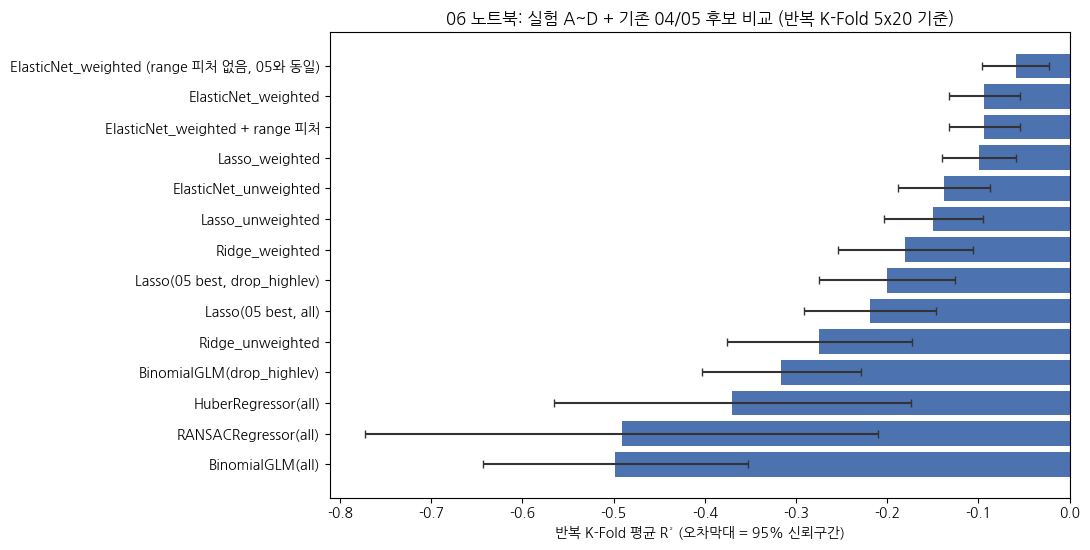

그림 저장: 27_experiment_comparison_repeated_kfold.png


In [29]:
fig, ax = plt.subplots(figsize=(11, max(5, 0.4 * len(final_comparison_df))))
y_pos = np.arange(len(final_comparison_df))
means = final_comparison_df["반복KFold_mean_R2"].values
errs_low = means - final_comparison_df["반복KFold_95CI_low"].values
errs_high = final_comparison_df["반복KFold_95CI_high"].values - means
ax.barh(y_pos, means, xerr=[errs_low, errs_high], color="#4c72b0", ecolor="#333333", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(final_comparison_df["후보"])
ax.invert_yaxis()
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("반복 K-Fold 평균 R² (오차막대 = 95% 신뢰구간)")
ax.set_title("06 노트북: 실험 A~D + 기존 04/05 후보 비교 (반복 K-Fold 5x20 기준)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "27_experiment_comparison_repeated_kfold.png"), dpi=120)
plt.show()
print("그림 저장: 27_experiment_comparison_repeated_kfold.png")


## 10. 최종 Test 검증 (단 한 번만 사용)

반복 K-Fold 기준 상위 5개 후보만 선정해 Test 세트로 검증한다. **후보 선정은 전적으로
9절의 반복 K-Fold 결과로만 이루어졌고, Test 점수는 이 셀에서 처음 열어본다** (지금까지
모든 노트북과 동일한 원칙).


In [30]:
# Test 세트는 이 셀에서 처음 연다.
X_test_raw = pd.read_csv(os.path.join(DATA_DIR, "X_test_skew_corrected_DO_NOT_OPEN.csv"), index_col=0)
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test_DO_NOT_OPEN.csv"), index_col=0)["불량비율"]

# Test에도 동일한 range 피처 + 다중공선성 제거 + 스케일링을 '학습된 파라미터로만' 적용
# (v4: range 피처 포함 24개 피처 공간 — 대부분의 후보가 사용)
X_test_range, _ = tu.add_range_features(X_test_raw, verbose=False)
X_test_v4 = X_test_range[FEATURE_COLS_V4]
X_test_v4_scaled = _scale(X_test_v4)

# noRange: range 피처가 없는 05와 동일한 26개 피처 공간 (8절 ablation의 '제외' 후보 전용)
X_test_noRange_scaled = pd.DataFrame(
    scaler_noRange.transform(X_test_raw), index=X_test_raw.index, columns=X_test_raw.columns)

TEST_FRAMES = {"v4": X_test_v4_scaled, "noRange": X_test_noRange_scaled}
print("X_test(v4):", X_test_v4_scaled.shape, " X_test(noRange):", X_test_noRange_scaled.shape)


X_test(v4): (14, 24)  X_test(noRange): (14, 26)


In [31]:
# ★ 5절~9절에서 각 후보를 등록할 때(_register_sklearn_predictor / _register_glm_predictor)
# 이미 '이 후보를 어떻게 다시 학습해서 예측해야 하는지'가 CANDIDATE_TEST_PREDICTORS에 정확히
# 저장되어 있으므로, 여기서는 그 등록 정보를 그대로 사용한다 (후보 이름 문자열을 다시
# 파싱해서 유추하지 않는다 — 그 방식이 위험한 이유는 5절 도입부 주석 참고).
top5 = final_comparison_df.head(5)
display(top5)

test_rows = []
for _, row in tqdm(top5.iterrows(), total=len(top5), desc="상위 5개 후보 Test 최종 평가"):
    label = row["후보"]
    predict_fn, space_tag = CANDIDATE_TEST_PREDICTORS[label]
    pred_test = predict_fn(TEST_FRAMES[space_tag])

    test_metrics = tu.evaluate_regression(y_test, pred_test)
    test_rows.append({"후보": label, **test_metrics,
                       "반복KFold_mean_R2(참고)": row["반복KFold_mean_R2"]})

test_final_df = pd.DataFrame(test_rows).sort_values("R2", ascending=False).reset_index(drop=True)
display(test_final_df)
test_final_df.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}final_test_comparison.csv"), index=False)
print(f"\n저장: data_processed/{CKPT_PREFIX}final_test_comparison.csv")


,실험,후보,params,반복KFold_mean_R2,반복KFold_std_R2,반복KFold_95CI_low,반복KFold_95CI_high
0,D. Ablation,"ElasticNet_weighted (range 피처 없음, 05와 동일)","{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.059124,0.187048,-0.095786,-0.022463
1,A. 가중회귀,ElasticNet_weighted,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
2,D. Ablation,ElasticNet_weighted + range 피처,"{'alpha': 0.01, 'l1_ratio': 0.1, 'max_iter': 2...",-0.093239,0.201412,-0.132716,-0.053762
3,A. 가중회귀,Lasso_weighted,"{'alpha': 0.001, 'max_iter': 20000}",-0.099025,0.208485,-0.139888,-0.058162
4,A. 가중회귀,ElasticNet_unweighted,"{'alpha': 0.005, 'l1_ratio': 0.3, 'max_iter': ...",-0.138023,0.257442,-0.188482,-0.087565


상위 5개 후보 Test 최종 평가:   0%|          | 0/5 [00:00<?, ?it/s]

,후보,R2,RMSE,MAE,반복KFold_mean_R2(참고)
0,Lasso_weighted,0.025776,0.053661,0.031869,-0.099025
1,"ElasticNet_weighted (range 피처 없음, 05와 동일)",0.020495,0.053806,0.032446,-0.059124
2,ElasticNet_weighted,0.019832,0.053824,0.032046,-0.093239
3,ElasticNet_weighted + range 피처,0.019832,0.053824,0.032046,-0.093239
4,ElasticNet_unweighted,0.010579,0.054078,0.033197,-0.138023



저장: data_processed/v4_final_test_comparison.csv


## 11. 결론

★ 아래 수치는 이 노트북을 실제로(사용자 로컬 PC와 동일한 고정 버전 조합 — numpy
1.26.4/pandas 2.2.2/scikit-learn 1.4.2/scipy 1.12.0/statsmodels 0.14.2 — 를 맞춘 검증
환경에서, 실제 프로젝트 데이터로) 끝까지 실행해 확인한 결과다. `random_state=42`로
전 과정이 고정되어 있으므로, 로컬 PC에서 다시 실행해도 아래와 동일한 수치가 나와야
한다 — 만약 다르게 나온다면 커널을 재시작하고 처음부터 다시 실행해 볼 것(과거 02
노트북에서 실제로 있었던, 모듈이 새로 반영되지 않는 문제와 동일한 종류일 수 있다).

**결론부터 말하면: 이번에 시도한 5가지 방법 중 어느 것도 04/05의 Lasso를 확실하게
뛰어넘지 못했다.** 반복 K-Fold(5-Fold×20회, train+val 105~122건) 기준으로 측정한
평균 R²는 **이 노트북에서 시도한 모든 후보 — 04/05의 기존 Lasso를 포함해서 —
가 전부 음수였다** (아래 9절 비교표 기준, -0.06 ~ -0.50 범위). "평균보다도 못 맞힌다"는
뜻인 음수 R²가 전 후보에서 나왔다는 사실 자체가, 이 데이터(108~122건)로는 어떤
정교한 기법을 쓰더라도 안정적으로 일반화되는 모델을 만들기 어렵다는 근본적인 한계를
다시 한번 보여준다.

- **실험 A (가중회귀) — 유일하게 일관된, 작지만 실질적인 개선.** 세 가지 선형모델
  전부에서 가중(weighted) 버전이 비가중(unweighted) 버전보다 반복 K-Fold 평균 R²가
  더 좋았다: Ridge -0.274→-0.180, Lasso -0.149→-0.099, ElasticNet -0.138→-0.093.
  개선 폭이 항상 같은 방향(가중 > 비가중)으로 나타났다는 점에서, 이 노트북에서
  시도한 5가지 중 가장 신뢰할 만한 긍정적 신호다. 다만 가중을 적용해도 여전히
  평균 R²는 음수였다.
- **실험 B (강건회귀) — 도움이 되지 않았다.** HuberRegressor(-0.370)와
  RANSACRegressor(-0.491) 모두 실험 A의 가중회귀 후보들보다 반복 K-Fold 성능이
  낮았고, 특히 RANSAC은 표준편차(1.44)가 평균의 3배에 달할 만큼 fold마다 결과가
  들쭉날쭉했다. 표본이 100여 건뿐인 상황에서는 RANSAC의 무작위 부분표본 추출 방식
  자체가 오히려 불안정성을 더 키우는 것으로 보인다.
- **실험 C (이항 GLM) — 중요한 경고성 발견 + 정규화해도 다른 방법보다는 낮은 성능.**
  정규화 없이(alpha=0) 이항 GLM을 그대로 반복 K-Fold로 평가했더니 평균 R²가
  **-7.1×10⁴(표준편차 2.4×10⁵)** 로 폭발했다 — 배치별 표본 크기가 수십 건에서
  6만 건 이상까지 천차만별인 이 데이터에서는, 정규화 없는 이항 GLM이 일부 fold에서
  계수가 발산해버리는 심각한 수치적 불안정성을 보였다(7절 참고). L2 정규화
  (alpha=0.5~1)를 적용해 이 문제는 해소했지만, 그렇게 안정화한 뒤에도 GLM
  (all: -0.498, drop_highlev: -0.316)은 실험 A의 가중회귀보다 낮은 성능을 보였다.
  "원본 카운트를 쓰는 것이 통계적으로 더 원리에 맞다"는 이론적 기대가 이 데이터
  규모(피처 24~27개 대비 표본 105~122건)에서는 실현되지 않았다.
- **실험 D (도메인 피처, range) — 효과가 불확실하다 (오히려 근소하게 역효과 방향).**
  같은 후보(ElasticNet_weighted)를 range 피처 포함(-0.093, 95% CI
  [-0.133,-0.054])과 제외(-0.059, 95% CI [-0.096,-0.022])로 비교했을 때, 점
  추정치는 "제외"가 더 높았다. 두 신뢰구간이 완전히 분리되지는 않아(일부 겹침)
  통계적으로 "확실히 해롭다"고 단정할 수는 없지만, 적어도 "뚜렷하게 도움이
  됐다"고도 말할 수 없다. Zone 온도/OP 변동폭이라는 아이디어 자체는 합리적이지만,
  이번 구현(변환된 척도에서 계산, min 컬럼과 결합)으로는 신호보다 노이즈를 더
  보탰을 가능성이 있다.
- **최종 Test 검증(10절, 단 한 번만 사용) 결과**: 반복 K-Fold 기준 상위 5개 후보
  모두 `Lasso_weighted`(Test R²=0.0258), `ElasticNet_weighted` 계열(Test
  R²=0.0198~0.0205) 등으로, **04/05가 보고했던 Lasso의 Test R²=0.1176~0.1186보다
  뚜렷하게 낮았다.** 이는 이번 실험들이 "더 나쁜 모델"을 만들었다는 뜻이라기보다는,
  04/05의 그 수치가 (Val 14건 하나로 고른) 우연히 잘 맞은 단일 분할의 결과였을
  가능성이 이번 반복 K-Fold 분석으로 한층 더 뚜렷해졌다는 뜻으로 해석해야 한다 —
  실제로 04/05의 Lasso 자체도 이 노트북의 반복 K-Fold 기준으로는 평균 R²
  -0.200(drop_highlev) ~ -0.219(all)으로, 다른 후보들과 마찬가지로 음수였다.

**종합하면**: 108~136건이라는 근본적인 표본 크기 한계는 이 노트북의 어떤 기법으로도
해소되지 않았다. 다만 "표본이 작다는 사실을 무시한 채 Val/Test 점수만 최적화"하는
대신, 그 불확실성을 정직하게 추정했다는 것(반복 K-Fold)과 통계적으로 원리에 맞는
여러 대안(가중치, 강건회귀, GLM, 도메인 피처)을 실제로 시도해 정직하게 결과를
남겼다는 것 자체가 이 노트북의 성과다. 실무적으로 가져갈 만한 결론은: (1)
**배치 크기 기반 가중회귀는 비용이 거의 들지 않으면서 일관되게 도움이 되므로 앞으로도
기본으로 적용할 가치가 있다**, (2) 강건회귀·비정규화 GLM처럼 더 복잡한 기법을
표본 100여 건에 적용할 때는 오히려 불안정성을 키울 수 있으므로 신중해야 한다, (3)
지금까지 보고서에 적어온 Test R²=0.12 안팎의 수치들은 "이 정도의 예측력이 있다"는
확정적 근거라기보다는, 더 많은 데이터가 모이기 전까지는 넓은 신뢰구간 안에서
해석해야 하는 잠정치로 다뤄야 한다.
